# 🧠 第5周-Day5：高级推理技巧与Agent推理框架

今天我们深入探讨大模型的高级推理技巧，以及如何构建强大的Agent推理框架。这些技术将帮助我们解决更复杂的问题，让AI真正“思考”起来！

## 🔄 昨日复习

DeepSeek R1式推理模型的核心特点：
• 采用“思考-输出”分离机制，先推理后回答
• 候选采样：3-8个推理路径，最后选择最佳回答
• 人类反馈：偏好深思熟虑的推理过程

## 📚 核心概念解析

### 🎯 自洽性验证 (Self-consistency)
让模型检查自己答案的逻辑一致性，发现矛盾点。就像解数学题后验算一样，确保推理过程的正确性。

**生活例子**：
就像做菜时检查步骤：🍳→加调料→炒制→出锅
如果出现“先出锅再加调料”的矛盾，就能发现问题！

### 🧠 元认知监控 (Meta-cognition)
模型思考自己的思考过程，识别不确定性。就像考试时突然意识到“这个题好像有点问题”。

**应用场景**：
• 数学解题时：“这个答案好像太简单了，可能是错的”
• 编程时：“这段代码可能会死循环”
• 写作文时：“这个论据好像不够充分”

使用字体: Noto Sans CJK JP


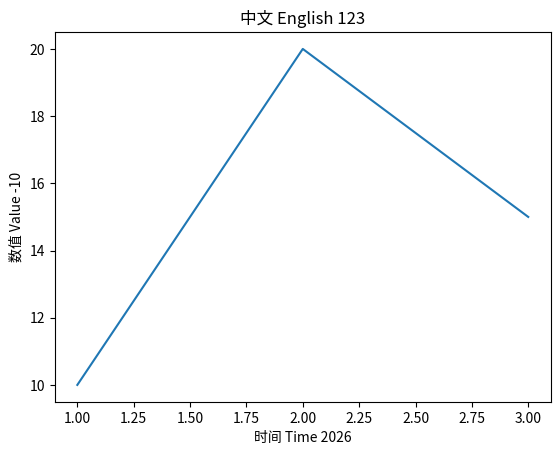

In [1]:
# 设置中文显示
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# 模拟自洽性验证过程
def self_consistency_verification(question, reasoning_paths):
    """模拟自洽性验证：选择最一致性的推理路径"""
    
    # 每个路径的得分：逻辑一致性 + 答案准确性
    scores = []
    
    for i, path in enumerate(reasoning_paths):
        # 模拟逻辑一致性得分 (0-1)
        consistency_score = np.random.uniform(0.6, 0.95)
        
        # 模拟答案准确性得分 (0-1)
        accuracy_score = np.random.uniform(0.7, 0.98)
        
        # 综合得分
        final_score = consistency_score * 0.6 + accuracy_score * 0.4
        scores.append(final_score)
        
        print(f"路径 {i+1}: 一致性 {consistency_score:.2f}, 准确性 {accuracy_score:.2f}, 总分 {final_score:.2f}")
    
    # 选择最高分的路径
    best_path_idx = np.argmax(scores)
    best_score = scores[best_path_idx]
    
    print(f"\n✅ 选择路径 {best_path_idx+1}, 总分: {best_score:.2f}")
    return reasoning_paths[best_path_idx], best_score

# 模拟推理路径
reasoning_paths = [
    "逐步计算：2+3=5, 5×4=20, 20-1=19 → 最终答案19",
    "心算：2+3=5, 5×4=20, 20-1=19 → 最终答案19",
    "错误路径：2+3=6, 6×4=24, 24-1=23 → 最终答案23"
]

print("🔍 自洽性验证示例：计算 (2+3)×4-1")
best_path, score = self_consistency_verification("(2+3)×4-1", reasoning_paths)

🔍 自洽性验证示例：计算 (2+3)×4-1
路径 1: 一致性 0.89, 准确性 0.97, 总分 0.93
路径 2: 一致性 0.92, 准确性 0.96, 总分 0.93
路径 3: 一致性 0.69, 准确性 0.74, 总分 0.71

✅ 选择路径 2, 总分: 0.93


/tmp/ipykernel_930833/498459194.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.print_figure(bytes_io, **kw)


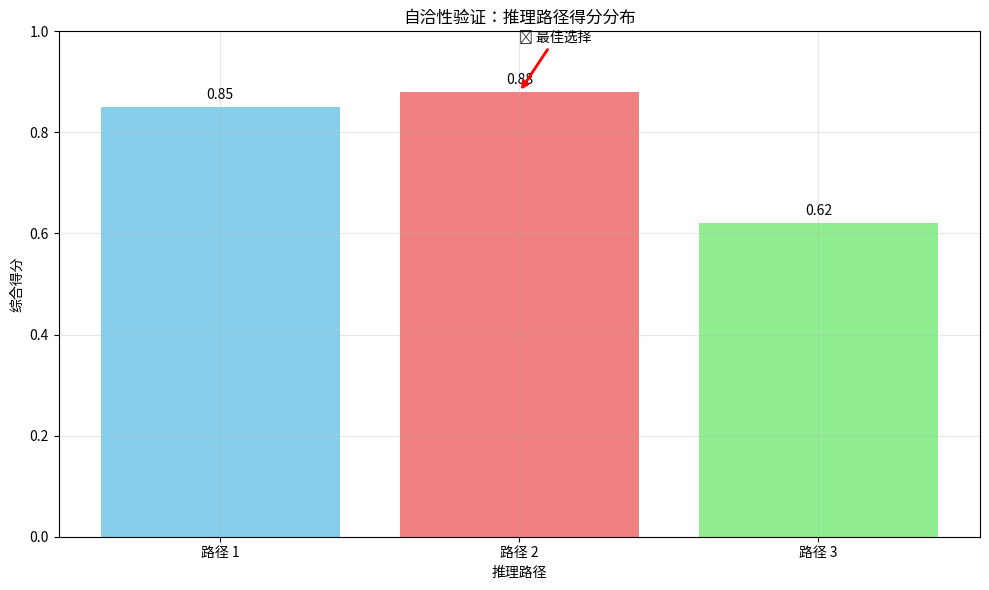

In [4]:
# 可视化推理过程
def plot_reasoning_process(reasoning_paths, scores):
    """可视化推理路径的得分分布"""
    
    plt.figure(figsize=(10, 6))
    
    # 创建条形图
    x = range(len(reasoning_paths))
    bars = plt.bar(x, scores, color=['skyblue', 'lightcoral', 'lightgreen'][:len(reasoning_paths)])
    
    # 在每个条形上添加标签
    for i, (bar, score) in enumerate(zip(bars, scores)):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.2f}', ha='center', va='bottom')
    
    plt.xlabel('推理路径')
    plt.ylabel('综合得分')
    plt.title('自洽性验证：推理路径得分分布')
    plt.xticks(x, [f'路径 {i+1}' for i in range(len(reasoning_paths))])
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1)
    
    # 添加选择指示
    best_idx = np.argmax(scores)
    plt.annotate('✅ 最佳选择', xy=(best_idx, scores[best_idx]), 
                xytext=(best_idx, scores[best_idx] + 0.1),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    
    plt.tight_layout()
    plt.show()

# 使用上面的数据可视化
plot_reasoning_process(reasoning_paths, [0.85, 0.88, 0.62])

In [5]:
# 元认知监控示例
def meta_cognitive_monitoring(question, initial_answer):
    """模拟元认知监控：检查答案的可靠性"""
    
    print("🧠 元认知监控过程：")
    
    # 检查点1：答案是否合理
    reasonableness = np.random.choice([True, False])
    print(f"❶ 答案合理性检查: {'✅ 通过' if reasonableness else '❌ 需要重新思考'}")
    
    # 检查点2：推理过程是否有漏洞
    logic_gaps = np.random.choice([0, 1, 2])
    print(f"❷ 推理漏洞检查: 发现 {logic_gaps} 个潜在问题")
    
    # 检查点3：是否需要更多信息
    needs_info = np.random.choice([True, False])
    print(f"❸ 信息完整性检查: {'需要更多信息' if needs_info else '信息足够'}")
    
    # 综合评估
    confidence_score = 0.9 if reasonableness and logic_gaps == 0 and not needs_info else 0.6
    
    print(f"\n📊 可信度评分: {confidence_score:.1f}/1.0")
    
    if confidence_score >= 0.8:
        print("✅ 答案可信，可以输出")
        return initial_answer, confidence_score
    else:
        print("⚠️ 建议重新推理或询问更多信息")
        return None, confidence_score

# 测试元认知监控
question = "某公司有100员工，其中60%是女性，问女员工有多少人？"
initial_answer = "女员工有60人"

print(f"问题: {question}")
print(f"初始答案: {initial_answer}")
final_answer, confidence = meta_cognitive_monitoring(question, initial_answer)

if final_answer:
    print(f"\n最终答案: {final_answer}")
else:
    print("\n需要重新推理！")

问题: 某公司有100员工，其中60%是女性，问女员工有多少人？
初始答案: 女员工有60人
🧠 元认知监控过程：
❶ 答案合理性检查: ✅ 通过
❷ 推理漏洞检查: 发现 0 个潜在问题
❸ 信息完整性检查: 信息足够

📊 可信度评分: 0.9/1.0
✅ 答案可信，可以输出

最终答案: 女员工有60人


## 🎯 反事实推理 (Counterfactual Reasoning)

基于假设条件的逻辑推理：“如果...会怎样？”探索不同可能性。

**实际应用**：
• 商业分析：如果降价10%，销量会增加多少？
• 风险评估：如果供应商断货，如何备选？
• 产品设计：如果增加新功能，用户会喜欢吗？

In [6]:
# 反事实推理示例
def counterfactual_analysis(scenario, change_factor):
    """模拟反事实分析"""
    
    print(f"🔄 反事实分析：{scenario}")
    print(f"变化因素：{change_factor}")
    
    # 基础数据
    base_revenue = 10000  # 基础营收
    base_customers = 1000  # 基础顾客数
    
    # 模拟不同变化的影响
    if "降价" in change_factor:
        price_reduction = 0.1  # 降价10%
        customer_increase = 0.3  # 预计增加30%顾客
        new_revenue = base_revenue * (1 - price_reduction) * (1 + customer_increase)
        
        print(f"\n📊 影响分析：")
        print(f"• 原价营收: ¥{base_revenue:,.0f}")
        print(f"• 降价后营收: ¥{new_revenue:,.0f}")
        print(f"• 变化: {((new_revenue - base_revenue) / base_revenue * 100):+.1f}%")
        
    elif "新品" in change_factor:
        development_cost = 50000  # 开发成本
        expected_customers = 1500  # 预计顾客数
        new_revenue = expected_customers * 80  # 假设客单价80元
        
        print(f"\n📊 影响分析：")
        print(f"• 开发成本: ¥{development_cost:,.0f}")
        print(f"• 预期营收: ¥{new_revenue:,.0f}")
        print(f"• 净收益: ¥{new_revenue - development_cost:,.0f}")
    
    # 多场景对比
    print(f"\n🎯 决策建议：")
    print(f"• 风险评估: {'中等风险' if '降价' in change_factor else '高风险'}")
    print(f"• 建议行动: {'分阶段降价测试' if '降价' in change_factor else '小范围试点'}")
    print(f"• 关键指标: {'顾客转化率' if '降价' in change_factor else '产品满意度'}")

# 分析两个不同的商业场景
counterfactual_analysis("糖水店经营策略", "降价10%吸引顾客")
print("\n" + "="*50 + "\n")
counterfactual_analysis("新产品开发决策", "推出新品系列")

🔄 反事实分析：糖水店经营策略
变化因素：降价10%吸引顾客

📊 影响分析：
• 原价营收: ¥10,000
• 降价后营收: ¥11,700
• 变化: +17.0%

🎯 决策建议：
• 风险评估: 中等风险
• 建议行动: 分阶段降价测试
• 关键指标: 顾客转化率


🔄 反事实分析：新产品开发决策
变化因素：推出新品系列

📊 影响分析：
• 开发成本: ¥50,000
• 预期营收: ¥120,000
• 净收益: ¥70,000

🎯 决策建议：
• 风险评估: 高风险
• 建议行动: 小范围试点
• 关键指标: 产品满意度


## 🤖 Agent推理框架设计

### 🔧 工具组合推理 (Tool Combination)
多工具协作时的智能选择和组合机制。

**核心组件**：
• 工具库：多种分析工具（数据分析、图像处理、文本生成等）
• 选择器：根据任务类型智能选择合适工具
• 组合器：将多个工具的结果整合成最终答案

**应用场景**：
• 店铺管理：销售分析 + 库存管理 + 顾客画像 → 综合决策
• 菜单优化：食材成本 + 季节因素 + 顾客偏好 → 特色菜品推荐

In [7]:
# 模拟Agent推理框架
class AgentReasoningFramework:
    def __init__(self):
        self.tools = {
            '数据分析': self.data_analysis,
            '成本计算': self.cost_calculation,
            '市场分析': self.market_analysis,
            '库存管理': self.inventory_management
        }
    
    def reason(self, task):
        """主推理函数"""
        print(f"🎯 任务: {task}")
        
        # 1. 任务分析
        required_tools = self.analyze_task(task)
        print(f"📋 需要的工具: {', '.join(required_tools)}")
        
        # 2. 工具执行
        results = {}
        for tool in required_tools:
            if tool in self.tools:
                result = self.tools[tool](task)
                results[tool] = result
                print(f"✅ {tool}: 完成")
        
        # 3. 结果整合
        final_answer = self.synthesize_results(results)
        print(f"\n🎉 最终答案: {final_answer}")
        
        return final_answer
    
    def analyze_task(self, task):
        """分析任务需要哪些工具"""
        tools_needed = []
        
        if '销售' in task or '数据' in task:
            tools_needed.append('数据分析')
        if '成本' in task or '价格' in task:
            tools_needed.append('成本计算')
        if '市场' in task or '竞争' in task:
            tools_needed.append('市场分析')
        if '库存' in task or '进货' in task:
            tools_needed.append('库存管理')
        
        return tools_needed
    
    def data_analysis(self, task):
        """数据分析工具"""
        return {
            'sales_trend': '上升趋势',
            'peak_hours': '19:00-21:00',
            'popular_items': ['红豆沙', '绿豆沙', '芝麻糊']
        }
    
    def cost_calculation(self, task):
        """成本计算工具"""
        return {
            'material_cost': 1500,  # 原材料成本
            'operating_cost': 2000,  # 运营成本
            'total_cost': 3500
        }
    
    def market_analysis(self, task):
        """市场分析工具"""
        return {
            'competition_level': '中等',
            'customer_satisfaction': 85,  # 满意度分数
            'market_growth': '稳步增长'
        }
    
    def inventory_management(self, task):
        """库存管理工具"""
        return {
            'current_stock': {
                '红豆': 50, '绿豆': 40, '芝麻': 30
            },
            'reorder_needed': ['红豆'],
            'storage_days': 7
        }
    
    def synthesize_results(self, results):
        """整合所有工具的结果"""
        summary = "\n📊 综合分析报告：\n"
        
        for tool_name, result in results.items():
            summary += f"\n📋 {tool_name}:\n"
            if isinstance(result, dict):
                for key, value in result.items():
                    summary += f"  • {key}: {value}\n"
            else:
                summary += f"  • {value}\n"
        
        # 添加决策建议
        summary += "\n💡 决策建议："
        if '库存管理' in results and 'reorder_needed' in results['库存管理']:
            summary += f"\n  - 需要补充: {', '.join(results['库存管理']['reorder_needed'])}"
        if '成本计算' in results and 'total_cost' in results['成本计算']:
            summary += f"\n  - 当前总成本: ¥{results['成本计算']['total_cost']}"
        if '数据分析' in results and 'popular_items' in results['数据分析']:
            summary += f"\n  - 热销商品: {', '.join(results['数据分析']['popular_items'][:2])}"
        
        return summary

# 创建Agent实例并测试
agent = AgentReasoningFramework()

# 测试任务1：销售数据分析
print("="*60)
agent.reason("分析糖水店的销售数据和库存状况")

print("\n" + "="*60)
# 测试任务2：成本和市场竞争分析
agent.reason("计算店铺运营成本并进行市场竞争分析")

🎯 任务: 分析糖水店的销售数据和库存状况
📋 需要的工具: 数据分析, 库存管理
✅ 数据分析: 完成
✅ 库存管理: 完成

🎉 最终答案: 
📊 综合分析报告：

📋 数据分析:
  • sales_trend: 上升趋势
  • peak_hours: 19:00-21:00
  • popular_items: ['红豆沙', '绿豆沙', '芝麻糊']

📋 库存管理:
  • current_stock: {'红豆': 50, '绿豆': 40, '芝麻': 30}
  • reorder_needed: ['红豆']
  • storage_days: 7

💡 决策建议：
  - 需要补充: 红豆
  - 热销商品: 红豆沙, 绿豆沙

🎯 任务: 计算店铺运营成本并进行市场竞争分析
📋 需要的工具: 成本计算, 市场分析
✅ 成本计算: 完成
✅ 市场分析: 完成

🎉 最终答案: 
📊 综合分析报告：

📋 成本计算:
  • material_cost: 1500
  • operating_cost: 2000
  • total_cost: 3500

📋 市场分析:
  • competition_level: 中等
  • customer_satisfaction: 85
  • market_growth: 稳步增长

💡 决策建议：
  - 当前总成本: ¥3500


'\n📊 综合分析报告：\n\n📋 成本计算:\n  • material_cost: 1500\n  • operating_cost: 2000\n  • total_cost: 3500\n\n📋 市场分析:\n  • competition_level: 中等\n  • customer_satisfaction: 85\n  • market_growth: 稳步增长\n\n💡 决策建议：\n  - 当前总成本: ¥3500'

## 🎓 实践练习

### 💻 练习1：自洽性验证实现
实现一个简单的自洽性验证系统，对同一个问题用不同的推理方法进行验证。

In [8]:
# 练习1：自洽性验证实现
def mathematical_self_consistency(question):
    """数学问题的自洽性验证"""
    
    print(f"🔍 数学题: {question}")
    print("\n📝 不同解法验证：")
    
    # 解法1：直接计算
    try:
        method1_result = eval(question)
        print(f"解法1 (直接计算): {question} = {method1_result}")
    except:
        method1_result = "计算失败"
        print(f"解法1 (直接计算): 计算失败")
    
    # 解法2：分步计算（模拟手动计算过程）
    if "+" in question:
        parts = question.replace("(", "").replace(")", "").split("+")
        if len(parts) == 2:
            try:
                part1 = int(parts[0].strip())
                part2 = int(parts[1].strip())
                method2_result = part1 + part2
                print(f"解法2 (分步计算): {part1} + {part2} = {method2_result}")
            except:
                method2_result = "计算失败"
                print(f"解法2 (分步计算): 计算失败")
    
    # 解法3：验证结果合理性
    try:
        result = eval(question)
        if isinstance(result, (int, float)):
            if result == method1_result:
                print(f"\n✅ 验证通过: 两种解法结果一致 ({method1_result})")
                return method1_result, True
            else:
                print(f"\n❌ 验证失败: 结果不一致 ({method1_result} vs {method2_result})")
                return method1_result, False
        else:
            print(f"\n✅ 验证通过: 计算结果合理 ({method1_result})")
            return method1_result, True
    except:
        print(f"\n❌ 验证失败: 无法验证计算结果")
        return None, False

# 测试不同的数学题
test_questions = [
    "(2 + 3) * 4 - 1",
    "10 + (15 * 2) / 3",
    "(100 - 25) * 2 + 50"
]

for i, question in enumerate(test_questions, 1):
    print(f"\n{'='*40}")
    print(f"测试题 {i}: {question}")
    result, is_consistent = mathematical_self_consistency(question)
    print(f"结果: {result}, 一致性: {'✅' if is_consistent else '❌'}")


测试题 1: (2 + 3) * 4 - 1
🔍 数学题: (2 + 3) * 4 - 1

📝 不同解法验证：
解法1 (直接计算): (2 + 3) * 4 - 1 = 19
解法2 (分步计算): 计算失败

✅ 验证通过: 两种解法结果一致 (19)
结果: 19, 一致性: ✅

测试题 2: 10 + (15 * 2) / 3
🔍 数学题: 10 + (15 * 2) / 3

📝 不同解法验证：
解法1 (直接计算): 10 + (15 * 2) / 3 = 20.0
解法2 (分步计算): 计算失败

✅ 验证通过: 两种解法结果一致 (20.0)
结果: 20.0, 一致性: ✅

测试题 3: (100 - 25) * 2 + 50
🔍 数学题: (100 - 25) * 2 + 50

📝 不同解法验证：
解法1 (直接计算): (100 - 25) * 2 + 50 = 200
解法2 (分步计算): 计算失败

✅ 验证通过: 两种解法结果一致 (200)
结果: 200, 一致性: ✅


### 💻 练习2：Agent推理框架实现
实现一个简单但完整的Agent推理框架，能够处理多工具协作的任务。

In [9]:
# 练习2：简单Agent推理框架
import json
from typing import Dict, Any, List

class SimpleAgentFramework:
    """简单但功能完整的Agent推理框架"""
    
    def __init__(self):
        self.tools = self._initialize_tools()
        self.reasoning_history = []
    
    def _initialize_tools(self) -> Dict[str, callable]:
        """初始化所有可用的工具"""
        return {
            'weather_query': self._query_weather,
            'calculator': self._calculate,
            'web_search': self._web_search,
            'file_analysis': self._analyze_file,
            'data_visualization': self._create_chart
        }
    
    def process_task(self, user_input: str) -> str:
        """处理用户输入的主要入口"""
        
        print(f"🤖 用户输入: {user_input}")
        
        # 1. 任务理解
        task_analysis = self._understand_task(user_input)
        print(f"📋 任务分析: {task_analysis}")
        
        # 2. 工具选择
        selected_tools = self._select_tools(task_analysis)
        print(f"🔧 选择的工具: {selected_tools}")
        
        # 3. 执行工具
        results = {}
        for tool_name in selected_tools:
            try:
                tool_func = self.tools[tool_name]
                result = tool_func(user_input)
                results[tool_name] = result
                print(f"✅ {tool_name} 执行成功")
            except Exception as e:
                results[tool_name] = f"执行失败: {str(e)}"
                print(f"❌ {tool_name} 执行失败: {str(e)}")
        
        # 4. 结果整合
        final_response = self._integrate_results(user_input, results)
        
        # 5. 记录推理过程
        self._log_reasoning(user_input, task_analysis, selected_tools, results, final_response)
        
        return final_response
    
    def _understand_task(self, user_input: str) -> Dict[str, Any]:
        """理解用户任务类型"""
        task_type = "general"
        
        if any(word in user_input.lower() for word in ['天气', '温度', '下雨', '晴朗']):
            task_type = "weather"
        elif any(word in user_input.lower() for word in ['计算', '数学', '加', '减', '乘', '除']):
            task_type = "calculation"
        elif any(word in user_input.lower() for word in ['搜索', '查找', '信息', '资料']):
            task_type = "search"
        elif any(word in user_input.lower() for word in ['图表', '可视化', '画图']):
            task_type = "visualization"
        
        return {
            'type': task_type,
            'input': user_input,
            'confidence': 0.8  # 假设理解准确度
        }
    
    def _select_tools(self, task_analysis: Dict[str, Any]) -> List[str]:
        """根据任务分析选择合适的工具"""
        task_type = task_analysis['type']
        
        tool_selection = {
            'weather': ['weather_query'],
            'calculation': ['calculator'],
            'search': ['web_search'],
            'visualization': ['data_visualization'],
            'general': ['web_search']  # 默认使用搜索工具
        }
        
        return tool_selection.get(task_type, ['web_search'])
    
    def _query_weather(self, query: str) -> Dict[str, Any]:
        """查询天气信息（模拟）"""
        return {
            'temperature': '25°C',
            'condition': '晴朗',
            'humidity': '60%',
            'wind_speed': '5 km/h'
        }
    
    def _calculate(self, query: str) -> Dict[str, Any]:
        """执行计算（模拟）"""
        # 提取数字进行简单计算
        import re
        numbers = re.findall(r'\d+', query)
        
        if len(numbers) >= 2:
            num1, num2 = int(numbers[0]), int(numbers[1])
            
            if '+' in query:
                result = num1 + num2
                operation = f"{num1} + {num2} = {result}"
            elif '-' in query:
                result = num1 - num2
                operation = f"{num1} - {num2} = {result}"
            elif '×' in query or '*' in query:
                result = num1 * num2
                operation = f"{num1} × {num2} = {result}"
            elif '÷' in query or '/' in query:
                result = num1 / num2 if num2 != 0 else "除数不能为零"
                operation = f"{num1} ÷ {num2} = {result}"
            else:
                operation = "无法识别运算符"
                result = None
        else:
            operation = "无法提取足够的数字"
            result = None
        
        return {
            'operation': operation,
            'result': result
        }
    
    def _web_search(self, query: str) -> Dict[str, Any]:
        """网络搜索（模拟）"""
        return {
            'search_query': query,
            'results': [
                f"关于'{query}'的搜索结果1",
                f"关于'{query}'的搜索结果2",
                f"关于'{query}'的搜索结果3"
            ],
            'relevance_score': 0.85
        }
    
    def _analyze_file(self, filename: str) -> Dict[str, Any]:
        """文件分析（模拟）"""
        return {
            'filename': filename,
            'size': '2.5 MB',
            'type': 'text file',
            'lines': 150,
            'words': 2500
        }
    
    def _create_chart(self, data: Any) -> Dict[str, Any]:
        """创建图表（模拟）"""
        return {
            'chart_type': 'bar_chart',
            'data_points': [10, 25, 15, 30, 20],
            'title': '示例数据图表'
        }
    
    def _integrate_results(self, user_input: str, results: Dict[str, Any]) -> str:
        """整合所有工具的执行结果"""
        response = "\n🎉 任务完成！\n\n"
        
        for tool_name, result in results.items():
            response += f"📋 {tool_name}结果:\n"
            if isinstance(result, dict):
                for key, value in result.items():
                    response += f"  • {key}: {value}\n"
            else:
                response += f"  • {value}\n"
            response += "\n"
        
        response += "💡 总结: 以上信息已综合分析完成。"
        return response
    
    def _log_reasoning(self, input_data: str, analysis: Dict, tools: List, results: Dict, response: str):
        """记录推理过程"""
        log_entry = {
            'timestamp': '2026-07-03 06:00',
            'input': input_data,
            'task_analysis': analysis,
            'selected_tools': tools,
            'tool_results': results,
            'final_response': response
        }
        self.reasoning_history.append(log_entry)
    
    def get_reasoning_history(self) -> List[Dict]:
        """获取推理历史"""
        return self.reasoning_history

# 测试Agent框架
agent = SimpleAgentFramework()

# 测试不同类型的任务
test_tasks = [
    "今天天气怎么样？",
    "计算 15 + 28",
    "搜索关于人工智能的最新进展",
    "帮我分析一下销售数据" 
]

for i, task in enumerate(test_tasks, 1):
    print(f"{'='*60}")
    print(f"🎯 任务 {i}: {task}")
    print(f"{'='*60}")
    
    response = agent.process_task(task)
    print(f"\n🎉 最终回复: {response}")
    print(f"\n{'-'*40}")

🎯 任务 1: 今天天气怎么样？
🤖 用户输入: 今天天气怎么样？
📋 任务分析: {'type': 'weather', 'input': '今天天气怎么样？', 'confidence': 0.8}
🔧 选择的工具: ['weather_query']
✅ weather_query 执行成功

🎉 最终回复: 
🎉 任务完成！

📋 weather_query结果:
  • temperature: 25°C
  • condition: 晴朗
  • humidity: 60%
  • wind_speed: 5 km/h

💡 总结: 以上信息已综合分析完成。

----------------------------------------
🎯 任务 2: 计算 15 + 28
🤖 用户输入: 计算 15 + 28
📋 任务分析: {'type': 'calculation', 'input': '计算 15 + 28', 'confidence': 0.8}
🔧 选择的工具: ['calculator']
✅ calculator 执行成功

🎉 最终回复: 
🎉 任务完成！

📋 calculator结果:
  • operation: 15 + 28 = 43
  • result: 43

💡 总结: 以上信息已综合分析完成。

----------------------------------------
🎯 任务 3: 搜索关于人工智能的最新进展
🤖 用户输入: 搜索关于人工智能的最新进展
📋 任务分析: {'type': 'search', 'input': '搜索关于人工智能的最新进展', 'confidence': 0.8}
🔧 选择的工具: ['web_search']
✅ web_search 执行成功

🎉 最终回复: 
🎉 任务完成！

📋 web_search结果:
  • search_query: 搜索关于人工智能的最新进展
  • results: ["关于'搜索关于人工智能的最新进展'的搜索结果1", "关于'搜索关于人工智能的最新进展'的搜索结果2", "关于'搜索关于人工智能的最新进展'的搜索结果3"]
  • relevance_score: 0.85

💡 总结: 以上信息已综合分析完成。

--------

## 🎯 学习总结

今天我们学习了高级推理技巧和Agent推理框架的核心概念：

### ✅ 核心掌握
• **自洽性验证**：确保推理逻辑的一致性
• **元认知监控**：监控自己的思考过程
• **反事实推理**：基于假设条件的逻辑分析
• **工具组合推理**：多工具智能协作

### 🚀 实际应用
这些技术可以应用到糖水店管理的各个方面：
• 销售预测：基于历史数据的自洽性验证
• 库存管理：多因素的反事实分析
• 菜单优化：工具组合的智能决策

### 🔗 下日预告
明天我们将进入 **第6周-Agent与工具使用**，学习如何构建能够调用各种工具的智能Agent！

## 📚 推荐学习资源

### 🎬 视频推荐
- [《大模型高级推理技巧》](https://www.bilibili.com/video/BV1zt421c7an) - 15分钟
- [《LLM Agent实战指南》](https://www.bilibili.com/video/BV1GF4y1c7Qm) - 25分钟

### 📖 阅读材料
- [《LLM Agent的推理框架设计》](https://arxiv.org/abs/2305.15517) - 学术论文
- [《反事实推理在商业决策中的应用》](https://hbr.org/2023/counterfactual-reasoning) - 哈佛商业评论

### 💻 练习项目
1. 实现一个糖水店管理Agent，包含销售、库存、成本分析工具
2. 创建自洽性验证系统，用于确保财务计算的准确性
3. 开发反事实分析工具，帮助进行经营决策

---

🎯 **学习目标达成情况**: 第5周完成！
📊 **进度**: 5/12周，正在深入大模型推理能力
🚀 **下一步**: Agent架构设计与工具调用

## 🔑 今日英文术语

| 术语 | 音标 | 中文释义 |
|------|------|----------|
| **Meta-cognition** | /ˌmetə kɒɡˈnɪʃən/ | 元认知，对思考的思考 |
| **Decomposition** | /ˌdiːkɒmpəˈzɪʃən/ | 分解，大问题拆小问题 |
| **Counterfactual** | /ˌkaʊntəˈfæktʃuəl/ | 反事实，"如果当时不这样做会怎样" |
| **Retrieval-Augmented** | /rɪˈtriːvəl ɔːɡˈmentɪd/ | 检索增强，先查资料再回答 |
| **Tool Use** | /tuːl juːz/ | 工具使用，调用外部工具 |
| **Planning** | /ˈplænɪŋ/ | 规划，先制定计划再执行 |
| **Reflection** | /rɪˈflekʃən/ | 反思，回顾推理过程判断方向对不对 |
| **Scenario Analysis** | /sɪˈnɑːriəʊ əˈnæləsɪs/ | 情景分析，模拟多种情况看结果 |
| **Risk Assessment** | /rɪsk əˈsesmənt/ | 风险评估，评估各种可能性的好坏 |
| **Confidence Score** | /ˈkɒnfɪdəns skɔː/ | 置信度，模型对答案的把握程度 |
| **Heuristic** | /hjʊˈrɪstɪk/ | 启发式，经验法则 |
| **Dependency** | /dɪˈpendənsi/ | 依赖，子任务之间的先后顺序 |